# Scale-Space Blob Detectors

## Exercise 1: Non-maxima supression

In [533]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rank_filter, gaussian_laplace
from skimage import io, color, img_as_float, transform
from show_all_circles import show_all_circles

In [534]:
def display(img):
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

In [535]:
# Define a 2-D coordinate grid with dimensions 100 × 100, 
# where both the x and y coordinates range from –10 to 10
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)


In [536]:
# Define a function to create a 2D Gaussian blob
def gaussian(x, y, x0, y0, sigma):
    """Generate a 2D Gaussian blob centered at (x0, y0) with standard deviation sigma."""
    return np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))

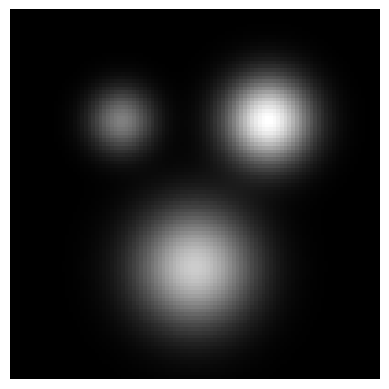

In [537]:
# Generate an image by combining three Gaussian blobs
# The Gaussians should be centered at:
# (-4, -4) with height of 5 and std of 1.2
# (4, -4) with a height of 10 and std of 1.6
# (0, 4) with a height of 8 and std of 2.2
blob1 = 5 * gaussian(X, Y, -4, -4, 1.2)
blob2 = 10 * gaussian(X, Y, 4, -4, 1.6)
blob3 = 8 * gaussian(X, Y, 0, 4, 2.2)

image = blob1 + blob2 + blob3

# Show the image
display(image)

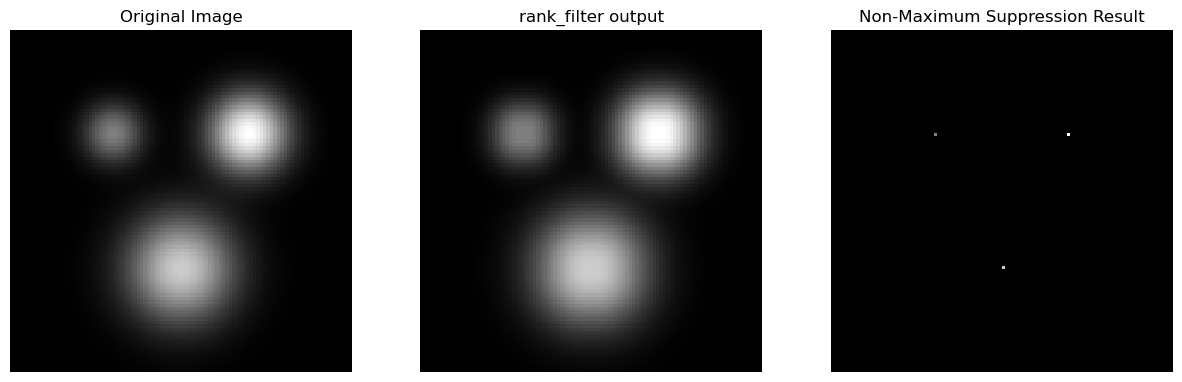

In [538]:
# Non-Maximum Suppression using rank_filter

# Apply rank_filter to the image with a filtersize of 3 and rank=1
max_filter_output = rank_filter(image, rank=-1, size=3)

# Combine the original image with the output of rank_filter
# to retain only the local maxima and suppress other values
nms_result = np.where(image == max_filter_output, image, 0)

# Display the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(max_filter_output, cmap='gray')
axes[1].set_title('rank_filter output')
axes[2].imshow(nms_result, cmap='gray')
axes[2].set_title('Non-Maximum Suppression Result')
for ax in axes:
    ax.axis('off')
plt.show()

In [3]:
import numpy as np
from scipy.ndimage import rank_filter

image = np.array([[5, 2, 3],
                  [9, 1, 4],
                  [7, 6, 8]])

# Apply 3x3 rank filter to get the minimum
result = rank_filter(image, rank=-1, size=3)
print(result)

[[9 9 4]
 [9 9 8]
 [9 9 8]]


## Exercise 2

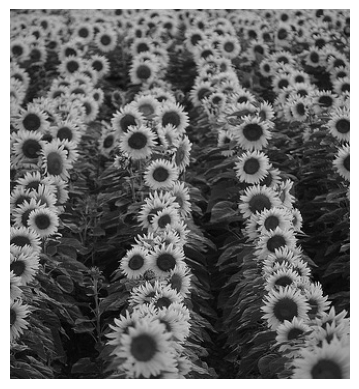

In [539]:
# Load and convert the image to grayscale
image = io.imread("sunflowers.jpg")
image_gray = color.rgb2gray(image)
image_gray = img_as_float(image_gray)

display(image_gray)

-0.009185850012159375 0.01176185689492484
5.439824695297607e-09 0.01176185689492484


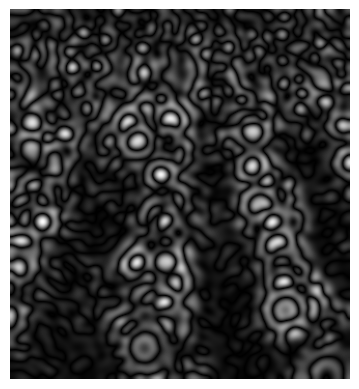

In [540]:
# Filter the image using the LoG filter
sigma = 5
log_image = gaussian_laplace(image_gray, sigma=sigma)

print(np.min(log_image), np.max(log_image))
log_image = np.abs(log_image)
print(np.min(log_image), np.max(log_image))

display(log_image)

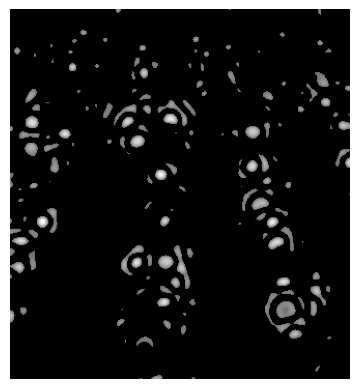

In [554]:
# Apply thresholding to the filtered image
threshold = 0.005
log_image = np.where(log_image > threshold, log_image, 0)

display(log_image)

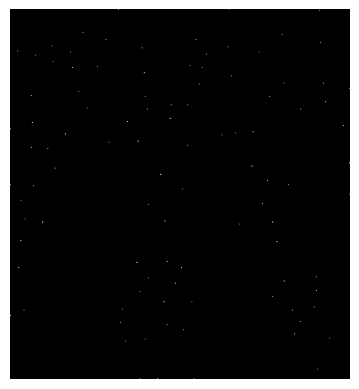

In [559]:
# Perform non-maximum suppression
max_filter_output = rank_filter(log_image, rank=-1, size=20)
nms_result = np.where(log_image == max_filter_output, log_image, 0)
display(nms_result)


In [560]:
# Extract blob centres
cy, cx = np.nonzero(nms_result)
rad = np.full_like(cx, sigma * np.sqrt(2))

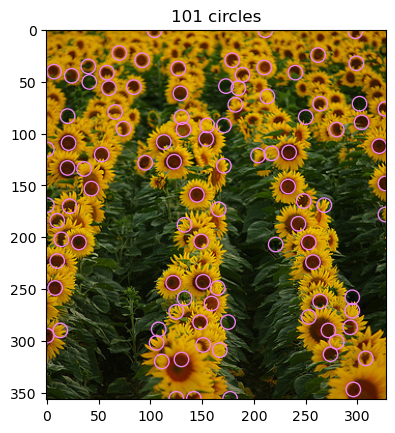

In [561]:
# Display final detections
show_all_circles(image, cx, cy, rad, color='violet')

## Exercise 3

In [ ]:
def scale_space_blob_detection(image, sigma0=3, S=4, No=4, threshold=0.07):
    """
    Perform scale-space blob detection using Laplacian of Gaussian (LoG) filtering.
    Parameters:
        image: Input grayscale image.
        sigma0: Initial scale (standard deviation) for LoG filter.
        S: Number of scales per octave.
        No: Number of octaves.
        k: Scale multiplication factor.
    Returns:
        List of detected blobs as (x, y, radius) tuples.
    """

    # Build scale space
    all_blobs = []

    for o in range(No):
        # Resize image for current octave
        scale_factor = 1 / (2 ** o)
        img_octave = transform.resize(image,
                                      (int(image.shape[0] * scale_factor),
                                                    int(image.shape[1] * scale_factor)))
        nms2d_responses = []
        sigmas = []

        for s in range(S):
            # Compute scales in this octave
            sigma = sigma0 * (2 ** o) * (2 ** (s / S))
            sigmas.append(sigma)

            # Apply LoG filter
            log_response = gaussian_laplace(img_octave, sigma=sigma)

            # Normalize the response
            log_response = np.abs(log_response) * (sigma ** 2)

            # Thresholding
            log_response = np.where(log_response > threshold, log_response, 0)

            # 2D non-maximum suppression
            max2d = rank_filter(log_response, rank=-1, size=10)
            nms2d = np.where(log_response == max2d, log_response, 0)

            nms2d_responses.append(nms2d)

        nms2d_responses = np.array(nms2d_responses)

        # 3D non-maximum suppression within each octave
        max3d = rank_filter(nms2d_responses, rank=-1, size=(3, 10, 10))
        nms3d = np.where(nms2d_responses == max3d, nms2d_responses, 0)

        # Extract blob centers
        scales, cy, cx = np.nonzero(nms3d)
        for s, y, x in zip(scales, cy, cx):
            x_orig = int(x / scale_factor)
            y_orig = int(y / scale_factor)
            radius = sigmas[s] * np.sqrt(2)
            all_blobs.append((x_orig, y_orig, radius))

    return all_blobs


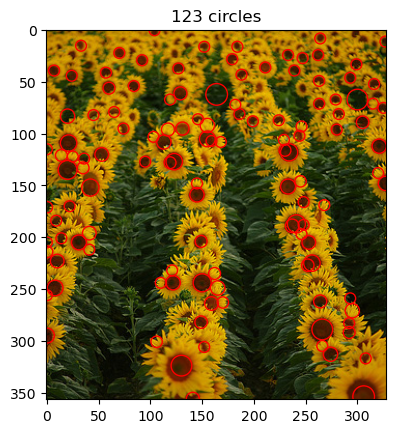

In [658]:
all_blobs = scale_space_blob_detection(image_gray, threshold=0.181, S=15, No=8, sigma0=3.7)
show_all_circles(image,
                 [b[0] for b in all_blobs],
                 [b[1] for b in all_blobs],
                 [b[2] for b in all_blobs],
                 color='RED')
